In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu



In [ ]:
df = pd.read_csv("../../data/training_data.csv")

custom_palette = ["#3d348b","#7678ed","#f7b801","#f18701","#f35b04",'#71cbd3','#ff3700']
STD_COLOR='0.2'
PAL=[custom_palette[5],custom_palette[6]]

dist_sc
con_sc


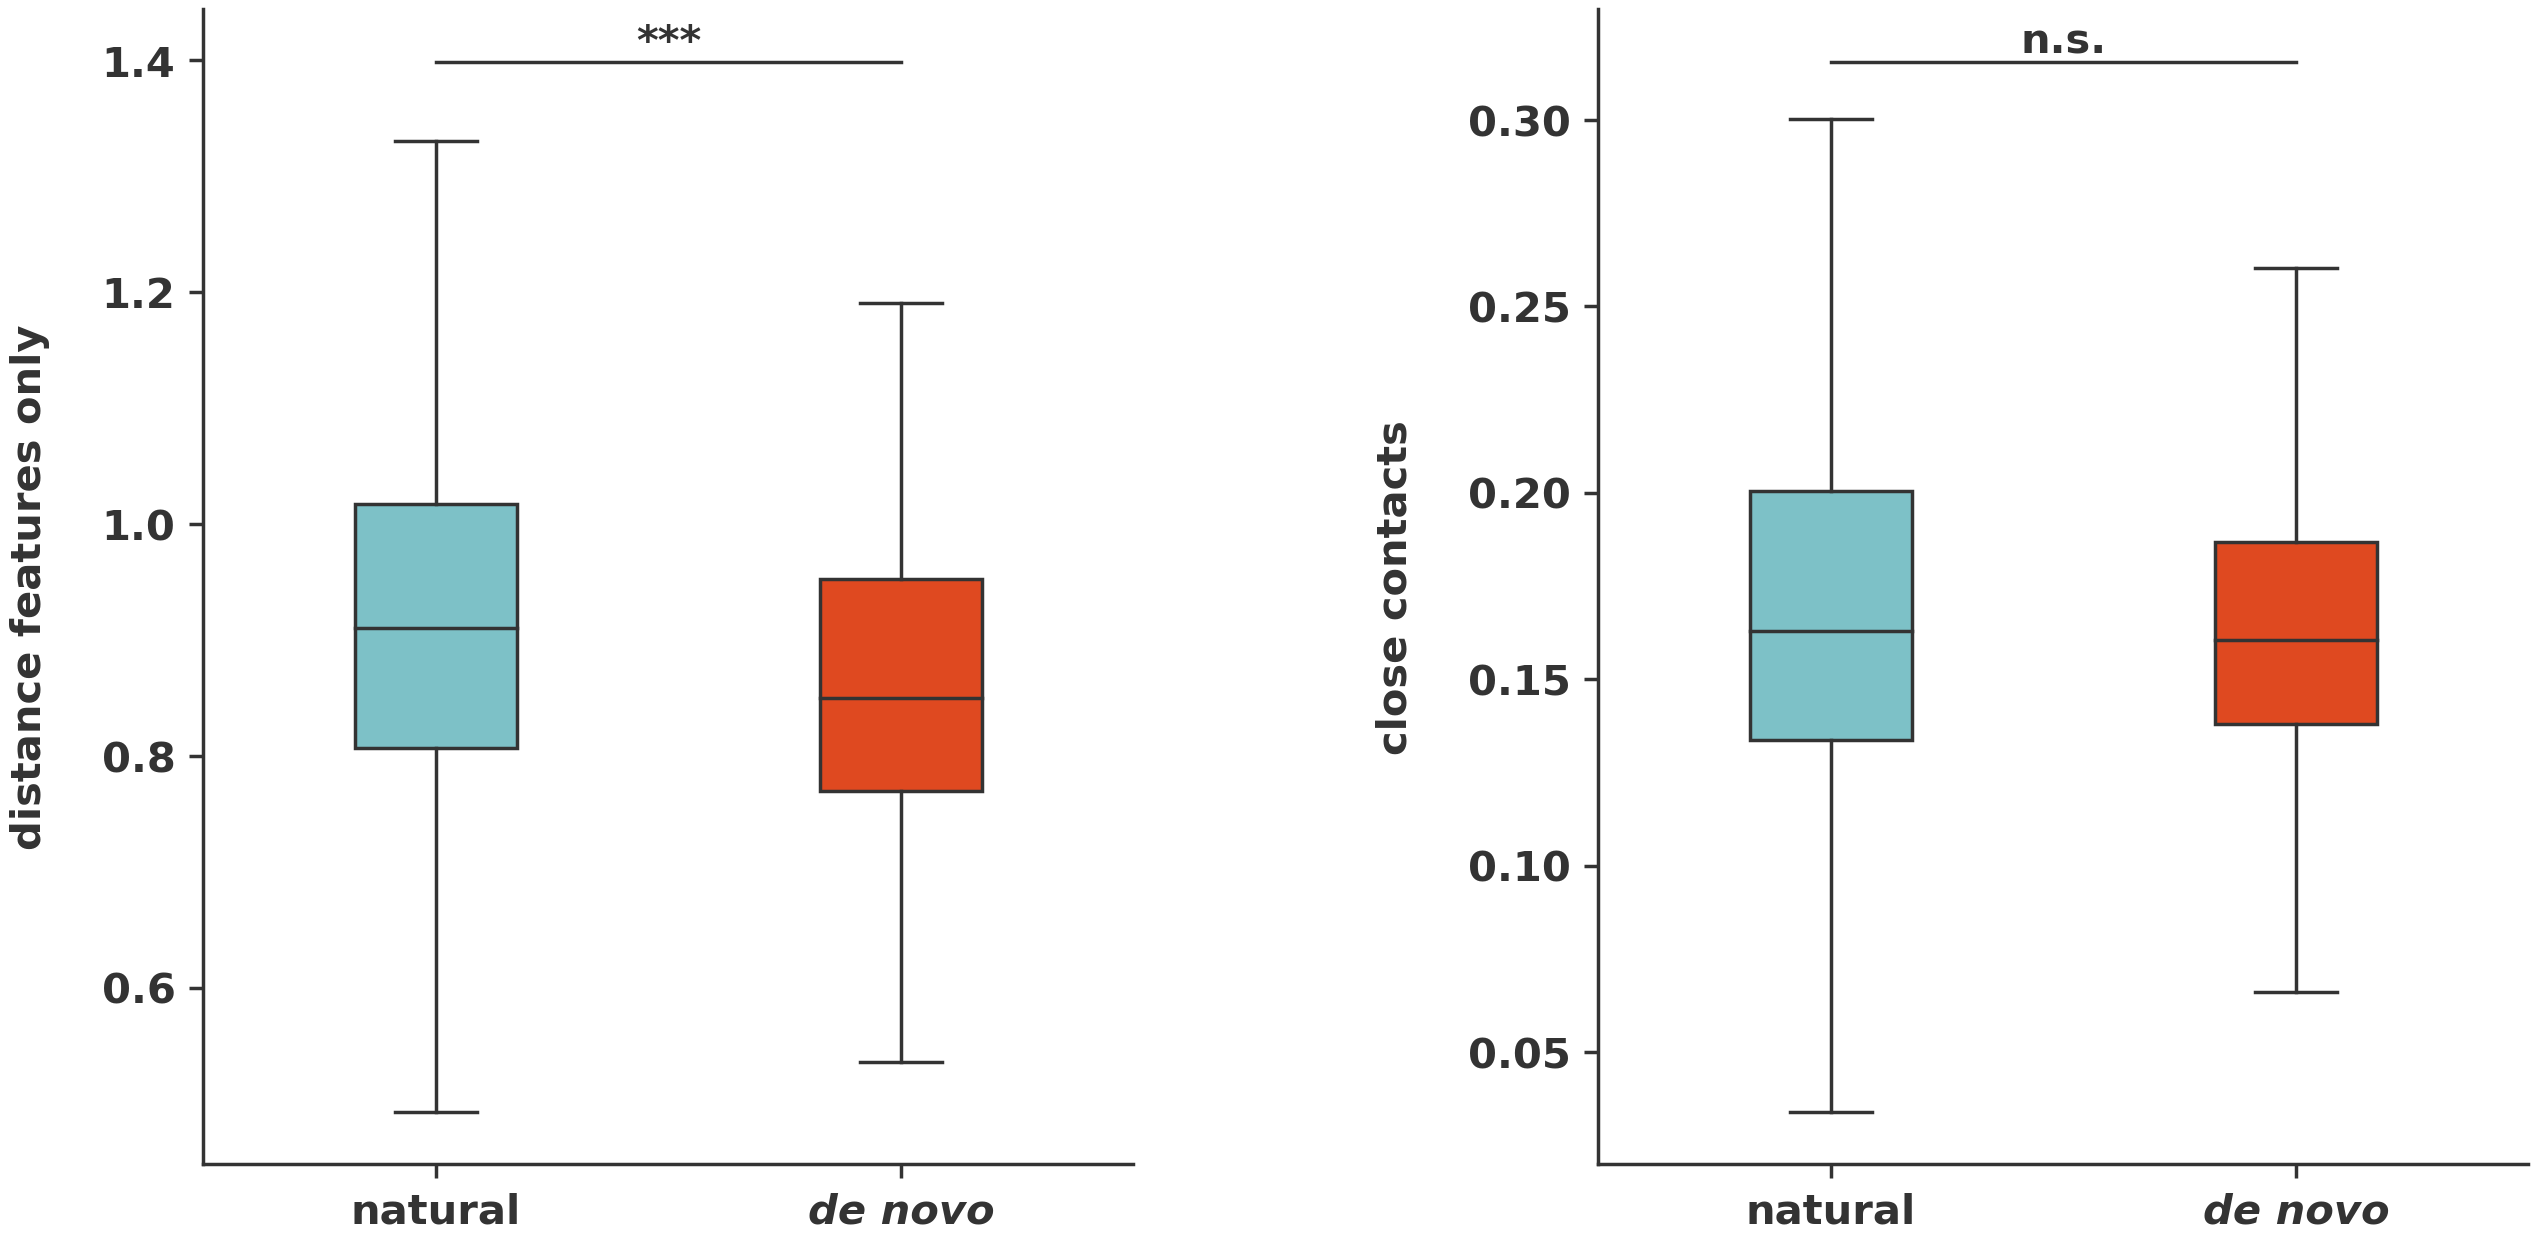

In [14]:
metrics=['dist_sc','con_sc']
title=['distance features only','close contacts']

kwargs_title={'fontsize':35, 'weight':'bold', 'color':STD_COLOR}
kwargs_label={'fontsize':30, 'weight':'bold', 'color':STD_COLOR}
kwargs_ticks={'fontsize':30, 'weight':'bold', 'color':STD_COLOR}
kwargs_box={'boxprops':{ 'edgecolor':STD_COLOR,'zorder':2}}


fig, ax = plt.subplots(1,2,figsize=(30,15))

for n, (metric, title) in enumerate(zip(metrics,title)):
    name = metric.replace("_"," ")

    
    ax_index = n

    print(metric)
    to_plot=metric


    sns.boxplot(x='type',y=to_plot,data=df,linewidth=2.5,width=.35,showfliers=False,palette=PAL, ax=ax[ax_index],**kwargs_box)
      
    
    if metric == 'per_no_con':
        ax[ax_index].set_yticklabels([0, 10, 20, 30, 40, 50, 60, 70, 80, 90],**kwargs_ticks)  
    
    if metric == 'per_con':
        ax[ax_index].set_yticklabels([12, 14, 16, 18, 20, 22, 24, 26, 28, 30],**kwargs_ticks)
        
    for line in ax[ax_index].lines:
        line.set_color(STD_COLOR) 

    ax[ax_index].set_ylabel(f'{title}\n',**kwargs_label)
    ax[ax_index].set_xlabel('')
    ax[ax_index].set_title('')

    ax[ax_index].set_xticklabels(['natural','de novo'],**kwargs_label)
    my_denovo= ax[ax_index].xaxis.get_ticklabels()[1]
    my_denovo.set_style('italic')
    
    yticks_locs, yticks_labels = ax[ax_index].get_yticks(), ax[ax_index].get_yticklabels()
    for label in yticks_labels:
        label.set_color(STD_COLOR)
        label.set_weight('bold')
        label.set_fontsize(30)


    for axis in ['bottom','left','top','right']:
        ax[ax_index].spines[axis].set_linewidth(2.5)
        ax[ax_index].spines[axis].set_color(STD_COLOR)

    ax[ax_index].spines['top'].set_visible(False)
    ax[ax_index].spines['right'].set_visible(False)
    ax[ax_index].tick_params(width=2.5,length=10,pad=10, color=STD_COLOR)

    
    plt.subplots_adjust(hspace=0.35,wspace=0.5) 
  

    Q1_0 = df[df['type'] == 0][to_plot].quantile(0.25)
    Q3_0 = df[df['type'] == 0][to_plot].quantile(0.75)
    IQR_0 = Q3_0 - Q1_0
    upper_border_0 = Q3_0 + 1.5 * IQR_0
    
    Q1_1 = df[df['type'] == 1][to_plot].quantile(0.25)
    Q3_1 = df[df['type'] == 1][to_plot].quantile(0.75)
    IQR_1= Q3_1 - Q1_1
    upper_border_1 = Q3_1 + 1.5 * IQR_1
    
    upper_border=max(upper_border_0,upper_border_1)
    y, h = upper_border + upper_border*0.05, 0
    ax[ax_index].plot([0, 0, 1, 1], [y, y+h, y+h, y], lw=2.5, c=STD_COLOR,clip_on=False)
    

    p_val = mannwhitneyu(df[df['type'] == 0][to_plot],df[df['type'] == 1][to_plot]).pvalue
    
    
    
    if p_val < .0005:
        ax[ax_index].text((0+1)*.5, y+h, "***", ha='center', va='bottom', color=STD_COLOR,fontdict={'fontsize':30,'weight':'bold'})
    elif p_val < .005:
        ax[ax_index].text((0+1)*.5, y+h, "**", ha='center', va='bottom', color=STD_COLOR,fontdict={'fontsize':30,'weight':'bold'})
    elif p_val < .05:
        ax[ax_index].text((0+1)*.5, y+h, "*", ha='center', va='bottom', color=STD_COLOR,fontdict={'fontsize':30,'weight':'bold'})
    else:
        ax[ax_index].text((0+1)*.5, y+h, "n.s.", ha='center', va='bottom', color=STD_COLOR,fontdict={'fontsize':30,'weight':'bold'})
        

        
plt.savefig('./nonpred_feature.png',dpi=300,bbox_inches='tight')

In [7]:
sub_df = df[df['type'] == 1]

In [8]:
max_index = sub_df['per_con'].idxmax()
max_row = sub_df.loc[max_index]
print(max_row)

-logP_Struc                       0.996275
-logP_Contact                       0.6226
dist_sc                           0.600234
con_sc                             0.16184
area_sc                           0.426682
per_con                           0.298725
per_no_con                        0.497931
contact_order                    13.807292
type                                     1
name             set/relax_6N9H_A_0001.pdb
Name: 3, dtype: object


In [9]:
import matplotlib.colors as mcolors
import colorsys

def hex_to_hue(hex_color):
    # Convert hex color to RGBA
    rgba = mcolors.to_rgba(hex_color)
    
    # Convert RGBA to RGB
    rgb = rgba[:3]
    
    # Convert RGB to HSV
    hsv = colorsys.rgb_to_hsv(*rgb)
    
    # Extract the hue value
    hue = hsv[0] * 360  # Multiply by 360 to get the hue in degrees
    
    return hue

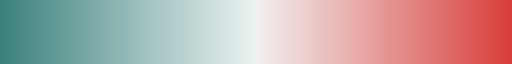

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# List of hex color codes
hex_colors = ["#71cbd3", "#ff3700", "#ff3700"]

# Create a diverging color palette
palette = sns.diverging_palette(hex_to_hue(hex_colors[0]), hex_to_hue(hex_colors[1]), n=10, as_cmap=True)
print(palette)
# Example usage with a plot
# sns.heatmap(np.arange(0,20000,50), cmap=palette)
# plt.show()
palette

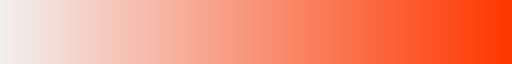

In [11]:
sns.light_palette("#ff3700", as_cmap=True)

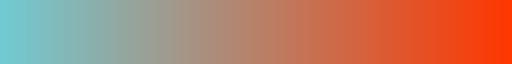

In [12]:

# sns.palplot(sns.diverging_palette("#71cbd3","#ff3700", center='light'))
sns.color_palette("blend:#71cbd3,#ff3700", as_cmap=True)